# Previsão de Popularidade de Músicas — Spotify

Análise exploratória e modelos preditivos para entender o que torna uma faixa popular no Spotify, usando um dataset com 114.000 faixas.


## 1. Carregamento e inspeção inicial dos dados



In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
df = pd.read_csv("dataset.csv", index_col=0)

In [72]:
df.shape

(114000, 20)

In [73]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='str')

In [74]:
df.dtypes

track_id                str
artists                 str
album_name              str
track_name              str
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str
dtype: object

In [75]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [76]:
df.describe(include="str")

,track_id,artists,album_name,track_name,track_genre
count,114000,113999,113999,113999,114000
unique,89741,31437,46589,73608,114
top,6S3JlDAGk3uu3NtZbPnuhS,The Beatles,Alternative Christmas 2022,Run Rudolph Run,acoustic
freq,9,279,195,151,1000


In [77]:
df.nunique()

track_id            89741
artists             31437
album_name          46589
track_name          73608
popularity            101
duration_ms         50697
explicit                2
danceability         1174
energy               2083
key                    12
loudness            19480
mode                    2
speechiness          1489
acousticness         5061
instrumentalness     5346
liveness             1722
valence              1790
tempo               45653
time_signature          5
track_genre           114
dtype: int64

## 2. Limpeza dos dados
Verificação de duplicatas, valores nulos e valores inválidos.



In [78]:
print("Duplicatas antes da limpeza:")
display(df['track_id'].duplicated().sum())
df = df.drop_duplicates(subset=["track_id"]).copy()
print("Duplicatas depois da limpeza:")
display(df['track_id'].duplicated().sum())

Duplicatas antes da limpeza:


np.int64(24259)

Duplicatas depois da limpeza:


np.int64(0)

In [79]:
df[df.duplicated(subset=['artists', 'track_name'], keep=False)].sort_values(['artists', 'track_name'])

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
58516,5h7RBt7uQCF788tr9Zy92j,(Hed) P.E.,Broke,Crazy Legs,25,242800,False,0.607,0.775,6,-5.427,1,0.2670,0.001950,0.000001,0.0915,0.736,102.051,4,industrial
58857,5igKQzi92vVl9Pjj86d42O,(Hed) P.E.,Broke,Crazy Legs,22,242960,True,0.523,0.810,6,-5.265,1,0.2940,0.001840,0.000001,0.0744,0.738,102.863,4,industrial
58306,7kv31DonKok7StOsCdvoBT,(Hed) P.E.,Broke,Waiting to Die,27,194800,True,0.581,0.962,8,-5.964,1,0.1210,0.000262,0.000011,0.1320,0.484,115.226,4,industrial
58874,0aiP8ezzmk3W1GRvnQYDCA,(Hed) P.E.,Broke,Waiting to Die,22,194626,False,0.577,0.964,2,-6.116,1,0.1200,0.000276,0.000048,0.1550,0.533,115.250,4,industrial
46055,4Fqm5rqB0WMx0hPOwgRjFr,2 Brothers On The 4th Floor,Dreams,Dreams (Will Come Alive),65,264000,False,0.702,0.953,7,-6.347,0,0.0473,0.011300,0.001930,0.2660,0.507,134.027,4,happy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70891,7DtuFvOjcJSFuCVeq3U7ns,吳青峰;Stefanie Sun,馬拉美的星期二,(......醉鬼阿Q)(feat. 孫燕姿),41,216399,False,0.586,0.790,7,-6.834,1,0.0453,0.025400,0.000761,0.1380,0.228,120.067,4,mandopop
5407,4qQTqlOWCftZYufh9uUzO9,大原ゆい子,旅人の唄,旅人の唄,47,264087,False,0.404,0.668,10,-5.746,0,0.0303,0.013700,0.000326,0.1230,0.495,136.980,3,anime
5879,7fgA5gjOjGlsIPLbUFvHDb,大原ゆい子,TVアニメ『無職転生 ~異世界行ったら本気だす~』Theme Song Collection,旅人の唄,43,264087,False,0.404,0.668,10,-5.746,0,0.0303,0.013700,0.000326,0.1230,0.495,136.980,3,anime
62250,1dGF5ymTyBB2ZmOypkeU1F,須田景凪,porte,veil,63,209636,False,0.559,0.873,0,-4.401,0,0.0543,0.028100,0.000000,0.1850,0.797,150.055,4,j-pop


In [80]:
print("Valores nulos antes da limpeza:")
display(df.isna().sum())
df = df.dropna(subset=["artists", "album_name", "track_name"])
print("Valores nulos depois da limpeza:")
df.isna().sum()

Valores nulos antes da limpeza:


track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Valores nulos depois da limpeza:


track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [81]:
print("Quantidade de valores 0 antes da limpeza:")
display((df[["tempo", "duration_ms", "time_signature"]] == 0).sum())
df = df[(df["tempo"] > 0) & (df["time_signature"] > 0) & (df["duration_ms"] > 0)]
print("Quantidade de valores 0 depois da limpeza:")
display((df[["tempo", "duration_ms", "time_signature"]] == 0).sum())

Quantidade de valores 0 antes da limpeza:


tempo             157
duration_ms         0
time_signature    162
dtype: int64

Quantidade de valores 0 depois da limpeza:


tempo             0
duration_ms       0
time_signature    0
dtype: int64

## 3. Análise Exploratória (EDA)
Correlação das features com popularidade e popularidade média por gênero.

In [82]:
sns.set_theme(style="whitegrid")
paleta = sns.color_palette("mako", as_cmap=False)
cor_spotify ="#1DB954"

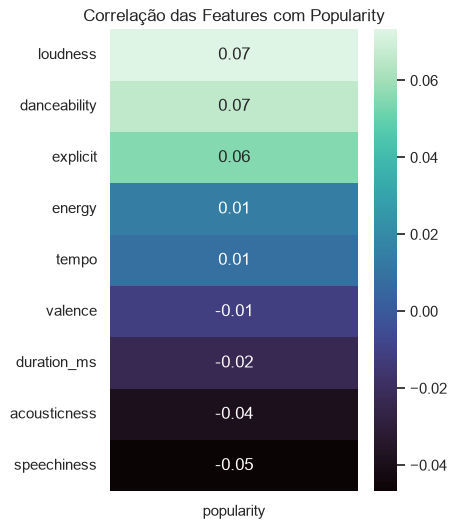

track_genre
k-pop       59.423581
pop-film    59.096933
metal       56.422414
chill       53.738683
latino      51.788945
sad         51.109929
grunge      50.587007
indian      49.765348
anime       48.776884
emo         48.500000
Name: popularity, dtype: float64

track_genre
idm               15.522222
kids              14.770791
grindcore         14.521827
classical         13.362168
chicago-house     12.333667
detroit-techno    11.130753
latin              9.855072
jazz               9.690249
romance            3.524917
iranian            2.233740
Name: popularity, dtype: float64

In [83]:
features = ["danceability", "energy", "loudness", "tempo" ,"valence", "explicit", "duration_ms", "speechiness", "acousticness", "popularity"]
correlacao = df[features].corr()[['popularity']].drop('popularity')
correlacao = correlacao.sort_values(by='popularity', ascending=False)

plt.figure(figsize=(4, 6))
sns.heatmap(correlacao, annot=True, cmap="mako", fmt=".2f")
plt.title("Correlação das Features com Popularity")
plt.show()

popularidade_por_genero = df.groupby("track_genre")["popularity"].mean().sort_values(ascending=False)
display(popularidade_por_genero.head(10))
display(popularidade_por_genero.tail(10))

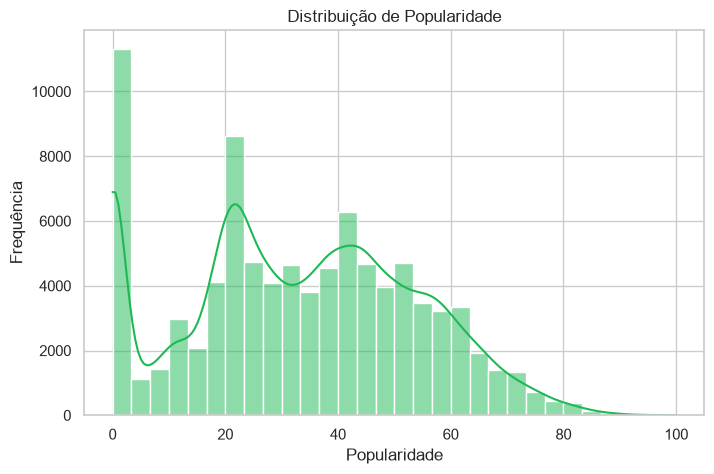

In [84]:
plt.figure(figsize=(8,5))
sns.histplot(df['popularity'], bins=30, kde=True, color=cor_spotify)
plt.title('Distribuição de Popularidade')
plt.xlabel('Popularidade')
plt.ylabel('Frequência')
plt.show()

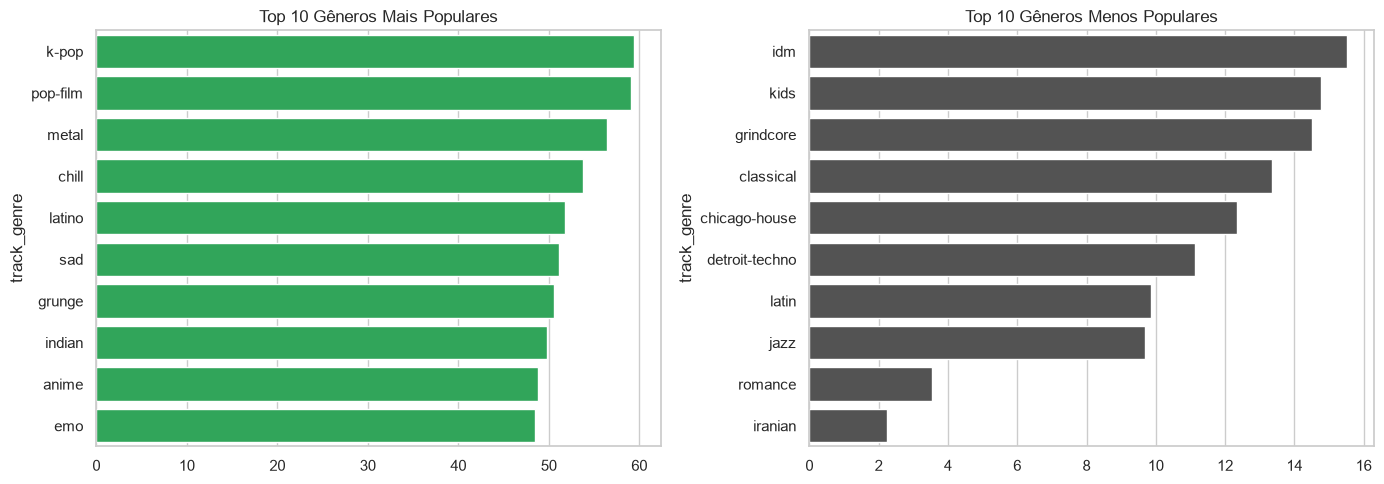

In [ ]:
top10 = popularidade_por_genero.head(10)
bottom10 = popularidade_por_genero.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.barplot(x=top10.values, y=top10.index, ax=axes[0], color=cor_spotify)
sns.barplot(x=bottom10.values, y=bottom10.index, ax=axes[1], color="#535353")
axes[0].set_title('Top 10 Gêneros Mais Populares')
axes[1].set_title('Top 10 Gêneros Menos Populares')
plt.tight_layout()
plt.show()

## 4. Modelagem

Testamos três modelos para prever a popularidade das faixas: KNN, Random Forest e XGBoost. Antes de treiná-los, preparamos os dados selecionando as features relevantes, aplicando one-hot encoding nos generos e separando em conjuntos de treino e teste.

In [86]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [87]:
features = ["danceability", "energy", "loudness", "tempo" ,"valence", "explicit", "duration_ms", "speechiness", "acousticness", "track_genre"]
df_knn = pd.get_dummies(df[features + ["popularity"]], columns=["track_genre"])
df_knn.columns
X = df_knn.drop(columns=["popularity"])
y = df_knn["popularity"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 4.1 KNN

In [88]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_normalizado = scaler.fit_transform(X_train)
X_test_normalizado = scaler.transform(X_test)

model = KNeighborsRegressor()
model.fit(X_train_normalizado, y_train)
y_pred = model.predict(X_test_normalizado)

mae_knn_normalizado = mean_absolute_error(y_test, y_pred)
r2_knn_normalizado = r2_score(y_test, y_pred)

print(f"MAE: {mae_knn_normalizado}")
print(f"R2: {r2_knn_normalizado}")

MAE: 10.888513060951105
R2: 0.36142173914942066


### 4.2 Random Forest

In [89]:
model_rf = RandomForestRegressor(random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE: {mae_rf}")
print(f"R2: {r2_rf}")

MAE: 10.085591308999547
R2: 0.4752593168901349


### 4.3 XGBoost

In [90]:
model_xgb = XGBRegressor(random_state=42, n_jobs=-1)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"MAE: {mae_xgb}")
print(f"R2: {r2_xgb}")

MAE: 11.246956825256348
R2: 0.40614962577819824


## 5. Conclusões

- O Random Forest foi o modelo com melhor desempenho entre os três testados.
- XGBoost treina significativamente mais rápido que Random Forest, um trade-off relevante para cenários de produção.
- Nenhum modelo atingiu um R² muito alto, o que sugere que grande parte da popularidade de uma faixa é influenciada por fatores fora do dataset (marketing, presença do artista, playlists editoriais).